# 03 — Event Detection & NLP

**DATSCI7030 · Causal Event-Driven Market Impact Modelling**  
Author: Ibrahim Haroun · LJMU 2025–2026 · Version 1.0

---

## Objectives

This notebook operationalises the 11,629 APP presidential documents and 89 FOMC events into a **unified, enriched event catalogue** ready for causal modelling in Phase 4.

### Pipeline stages

| Step | Description | Output |
|------|-------------|--------|
| 3.1 | Load & audit all raw datasets | Validation summary |
| 3.2 | Rule-based event classification | `event_type` column on APP docs |
| 3.3 | FinBERT sentiment scoring (titles) | `sentiment_label`, `sentiment_score`, `sentiment_numeric` |
| 3.4 | FOMC event enrichment | FOMC entries added to catalogue |
| 3.5 | GDELT geopolitical risk integration | Daily Goldstein / tone scores |
| 3.6 | Unified event catalogue construction | `events_tagged.parquet` |
| 3.7 | Daily sentiment time series | `daily_sentiment.parquet` |
| 3.8 | High-impact event flagging | `high_impact_events.parquet` |
| 3.9 | Visualisations & validation | Figures saved to `reports/figures/` |

### Key design decisions
- **Text source**: Document titles only (avg 80 chars). The `text_snippet` field was collected but is empty in the raw data — full text scraping is planned for Phase 3b if sentiment signal is weak.
- **FinBERT**: `ProsusAI/finbert` fine-tuned on financial news — ideal for policy/market titles. Requires PyTorch. A keyword-based fallback is used if torch is unavailable.
- **Event taxonomy**: 8 categories derived from domain knowledge — monetary, trade, geopolitical, regulatory, energy, health, labour, other.

**Outputs**: `data/processed/events_tagged.parquet`, `data/processed/daily_sentiment.parquet`, `data/processed/high_impact_events.parquet`

---
## 3.0 Environment Setup

In [1]:
import os, sys, warnings, re
from pathlib import Path

# ── HuggingFace token (prevents unauthenticated rate-limit warning) ────────────
os.environ.setdefault('HF_TOKEN', os.getenv('HF_TOKEN', ''))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 20)
pd.set_option('display.max_colwidth', 80)

# ── Paths ──────────────────────────────────────────────────────────────────────
ROOT      = Path('..').resolve()
RAW       = ROOT / 'data' / 'raw'
PROCESSED = ROOT / 'data' / 'processed'
FIGURES   = ROOT / 'reports' / 'figures'
PROCESSED.mkdir(parents=True, exist_ok=True)
FIGURES.mkdir(parents=True, exist_ok=True)

# ── Plot style ─────────────────────────────────────────────────────────────────
plt.rcParams.update({
    'figure.dpi': 150,
    'figure.facecolor': 'white',
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'font.size': 10,
})
PALETTE = ['#1f4e79','#2e75b6','#c55a11','#70ad47','#7030a0','#ff0000','#00b0f0','#ffc000']

# ── FinBERT availability check ─────────────────────────────────────────────────
FINBERT_AVAILABLE = False
try:
    import torch
    from transformers import pipeline as hf_pipeline
    FINBERT_AVAILABLE = True
    print(f'✓ PyTorch {torch.__version__} | transformers available — FinBERT will run')
except ImportError:
    print('⚠ PyTorch/transformers not available — using lexicon fallback')
    print('  pip install torch --index-url https://download.pytorch.org/whl/cpu')
    print('  pip install transformers')

print(f'\nROOT      : {ROOT}')
print(f'PROCESSED : {PROCESSED}')
print(f'FIGURES   : {FIGURES}')
print(f'FinBERT   : {FINBERT_AVAILABLE}')

✓ PyTorch 2.11.0 | transformers available — FinBERT will run

ROOT      : /Users/ibby/dev/LJMU/7030DATSCI-Data-Science-Project/DATSCI7030
PROCESSED : /Users/ibby/dev/LJMU/7030DATSCI-Data-Science-Project/DATSCI7030/data/processed
FIGURES   : /Users/ibby/dev/LJMU/7030DATSCI-Data-Science-Project/DATSCI7030/reports/figures
FinBERT   : True


---
## 3.1 Load & Audit Raw Datasets

In [2]:
# ── Load all raw datasets ──────────────────────────────────────────────────────
app    = pd.read_parquet(RAW / 'app_presidential_documents.parquet')
fomc   = pd.read_parquet(RAW / 'fomc_dates.parquet')
gdelt  = pd.read_parquet(RAW / 'gdelt_sample.parquet')
prices = pd.read_parquet(RAW / 'prices.parquet')
# VIX has date as index — reset to column
vix    = pd.read_parquet(RAW / 'vix.parquet').reset_index()

# ── Date normalisation ─────────────────────────────────────────────────────────
app['date']    = pd.to_datetime(app['date']).dt.normalize()
fomc['date']   = pd.to_datetime(fomc['date']).dt.normalize()
gdelt['date']  = pd.to_datetime(gdelt['date']).dt.normalize()
prices['date'] = pd.to_datetime(prices['date']).dt.normalize()
vix['date']    = pd.to_datetime(vix['date']).dt.normalize()

# ── Audit summary ──────────────────────────────────────────────────────────────
print('=' * 60)
print('DATASET AUDIT')
print('=' * 60)
datasets = {
    'APP Presidential Documents': app,
    'FOMC Meeting Dates':         fomc,
    'GDELT Events':               gdelt,
    'Market Prices':              prices,
    'VIX':                        vix,
}
for name, df in datasets.items():
    print(f'\n{name}')
    print(f'  Shape:   {df.shape[0]:,} rows × {df.shape[1]} cols')
    print(f'  Dates:   {df["date"].min().date()} → {df["date"].max().date()}')
    print(f'  Nulls:   {df.isnull().sum().sum()}')
print()

# ── APP breakdown ──────────────────────────────────────────────────────────────
print('APP document breakdown by type:')
print(app['doc_type'].value_counts().to_string())
print()
print('APP document breakdown by president:')
print(app['president'].value_counts().to_string())

# Core presidents for modelling (exclude minor entries)
CORE_PRESIDENTS = [
    'Barack Obama',
    'Donald J. Trump (1st Term)',
    'Joseph R. Biden, Jr.',
    'Donald J. Trump (2nd Term)',
]


DATASET AUDIT

APP Presidential Documents
  Shape:   11,629 rows × 7 cols
  Dates:   2015-01-01 → 2025-12-31
  Nulls:   0

FOMC Meeting Dates
  Shape:   89 rows × 4 cols
  Dates:   2015-01-28 → 2025-12-10
  Nulls:   0

GDELT Events
  Shape:   2,405 rows × 10 cols
  Dates:   2026-05-02 → 2026-05-06
  Nulls:   1088

Market Prices
  Shape:   2,765 rows × 5 cols
  Dates:   2015-01-02 → 2025-12-30
  Nulls:   0

VIX
  Shape:   2,765 rows × 2 cols
  Dates:   2015-01-02 → 2025-12-30
  Nulls:   0

APP document breakdown by type:
doc_type
spoken_addresses     4792
statements           2299
press_conferences    2080
proclamations        1773
executive_orders      685

APP document breakdown by president:
president
Joseph R. Biden, Jr.          5145
Donald J. Trump (1st Term)    3373
Barack Obama                  1988
Donald J. Trump (2nd Term)    1064
Kamala Harris                   32
Mike Pence                      18
George W. Bush                   2
Hillary Clinton                  2
U.S. Co

---
## 3.2 Rule-Based Event Classification

Each document is assigned an **event type** using keyword matching on its title. The taxonomy covers 8 market-relevant categories derived from the financial event-study literature. This runs fast (no ML required) and provides a deterministic baseline.

Categories: `monetary`, `trade`, `geopolitical`, `regulatory`, `energy`, `health`, `labour`, `other`

In [3]:
# ── Event taxonomy — ordered by priority (first match wins) ───────────────────
EVENT_TAXONOMY = [
    ('monetary', [
        'federal reserve', 'fed ', 'interest rate', 'monetary policy', 'fomc',
        'quantitative easing', 'rate hike', 'rate cut', 'inflation', 'cpi',
        'treasury', 'bond', 'yield', 'deficit', 'debt ceiling', 'budget',
        'fiscal', 'stimulus', 'relief package', 'spending bill', 'appropriation',
        'tax cut', 'tax reform', 'economic recovery',
    ]),
    ('trade', [
        'trade', 'tariff', 'import', 'export', 'china trade', 'trade war',
        'nafta', 'usmca', 'wto', 'trade deal', 'trade agreement', 'commerce',
        'free trade', 'intellectual property', 'supply chain',
    ]),
    ('geopolitical', [
        'war', 'conflict', 'military', 'sanction', 'nato', 'russia', 'ukraine',
        'iran', 'north korea', 'terrorism', 'attack', 'defense',
        'national security', 'nuclear', 'missile', 'troops', 'withdrawal',
        'foreign policy', 'diplomat', 'embassy', 'coup', 'refugee',
        'immigration', 'border', 'asylum', 'israel', 'middle east',
    ]),
    ('regulatory', [
        'executive order', 'regulation', 'deregulation', 'sec ', 'antitrust',
        'lawsuit', 'fine', 'penalty', 'ban ', 'restriction', 'compliance',
        'dodd-frank', 'clean air', 'clean water', 'environmental',
        'proclamation', 'signing statement', 'veto', 'legislation', 'bill',
    ]),
    ('energy', [
        'oil', 'gas', 'energy', 'pipeline', 'keystone', 'opec',
        'renewable', 'climate', 'carbon', 'paris agreement', 'green',
        'solar', 'wind power', 'coal', 'drilling', 'offshore',
    ]),
    ('health', [
        'covid', 'pandemic', 'vaccine', 'virus', 'health care', 'healthcare',
        'opioid', 'drug', 'fda', 'aca', 'affordable care', 'medicare',
        'medicaid', 'public health', 'disease', 'outbreak',
    ]),
    ('labour', [
        'jobs', 'employment', 'unemployment', 'worker', 'wage', 'minimum wage',
        'union', 'workforce', 'infrastructure', 'manufacturing', 'factory',
    ]),
]

def classify_event_type(title: str) -> str:
    """Assign event type from title using priority keyword matching."""
    if not isinstance(title, str):
        return 'other'
    t = title.lower()
    for event_type, keywords in EVENT_TAXONOMY:
        if any(kw in t for kw in keywords):
            return event_type
    return 'other'

# Apply classification
app = app.copy()
app['event_type'] = app['title'].apply(classify_event_type)

# Report
print('Event type distribution (APP documents):')
ev_counts = app['event_type'].value_counts()
for et, n in ev_counts.items():
    pct = 100 * n / len(app)
    bar = '█' * int(pct / 2)
    print(f'  {et:>12s}  {n:5,d}  ({pct:5.1f}%)  {bar}')
print()

# Sample titles from each type for sanity check
print('Sample titles per event type (3 each):')
for et in ev_counts.index:
    samples = app[app['event_type'] == et]['title'].head(3).tolist()
    print(f'\n  [{et.upper()}]')
    for s in samples:
        print(f'    • {s[:90]}')

Event type distribution (APP documents):
         other  6,423  ( 55.2%)  ███████████████████████████
    regulatory  2,246  ( 19.3%)  █████████
  geopolitical  1,628  ( 14.0%)  ██████
        health    449  (  3.9%)  █
         trade    277  (  2.4%)  █
        labour    243  (  2.1%)  █
      monetary    204  (  1.8%)  
        energy    159  (  1.4%)  

Sample titles per event type (3 each):

  [OTHER]
    • Statement on the Death of Mario M. Cuomo
    • Statement on the Death of Stuart O. Scott
    • Press Briefing by Press Secretary Josh Earnest

  [REGULATORY]
    • Statement on the Resignation of Acting Chair of the Council on Environmental Quality Micha
    • Proclamation 9227—Religious Freedom Day, 2015
    • Executive Order 13688—Federal Support for Local Law Enforcement Equipment Acquisition

  [GEOPOLITICAL]
    • Executive Order 13687—Imposing Additional Sanctions With Respect to North Korea
    • Statement on the Death of Former Senator Edward W. Brooke III
    • Remarks 

---
## 3.3 FinBERT Sentiment Scoring

**Model**: `ProsusAI/finbert` — BERT fine-tuned on 4,500 financial news sentences. Outputs `positive`, `negative`, `neutral` with a confidence score.

**Input**: Document titles (avg 80 chars). Titles fit within the 512-token window without truncation in nearly all cases.

**Numeric encoding**: `positive → +1`, `neutral → 0`, `negative → −1`.

**Fallback**: If PyTorch is unavailable, a curated financial lexicon scorer is used instead.

In [4]:
# ── Lexicon-based fallback scorer ──────────────────────────────────────────────
POSITIVE_WORDS = {
    'agreement', 'growth', 'recovery', 'reform', 'success', 'peace',
    'progress', 'approve', 'sign', 'support', 'partnership', 'cooperation',
    'strengthen', 'increase', 'improve', 'expand', 'invest', 'celebrate',
    'achieve', 'historic', 'landmark', 'benefit', 'relief', 'aid', 'help',
    'protect', 'save', 'create', 'build', 'launch', 'better',
    'stronger', 'record', 'jobs', 'employment', 'boost', 'gain', 'rise',
    'tax relief', 'restore', 'advance', 'secure',
}
NEGATIVE_WORDS = {
    'sanction', 'war', 'attack', 'conflict', 'death', 'crisis', 'threat',
    'ban', 'restrict', 'penalty', 'fine', 'lawsuit', 'investigate', 'fraud',
    'tariff', 'terror', 'violence', 'disaster', 'emergency', 'recession',
    'deficit', 'debt', 'default', 'shutdown', 'veto', 'oppose', 'fail',
    'layoff', 'loss', 'decline', 'fall', 'drop', 'reduce', 'risk',
    'missile', 'nuclear', 'shooting', 'murder', 'opioid',
    'covid', 'pandemic', 'outbreak', 'inflation', 'surge', 'corruption',
}

def lexicon_sentiment(title: str):
    """Simple lexicon-based sentiment. Returns (label, score)."""
    if not isinstance(title, str):
        return 'neutral', 0.5
    t = title.lower()
    pos = sum(1 for w in POSITIVE_WORDS if w in t)
    neg = sum(1 for w in NEGATIVE_WORDS if w in t)
    if pos > neg:
        return 'positive', min(0.5 + 0.1 * (pos - neg), 0.95)
    elif neg > pos:
        return 'negative', min(0.5 + 0.1 * (neg - pos), 0.95)
    else:
        return 'neutral', 0.5

print('Lexicon scorer ready. Sanity check:')
test_titles = [
    'Executive Order Imposing Sanctions on Russia for Ukraine Invasion',
    'Remarks on the Economic Recovery and Job Creation Act',
    'Press Briefing by Press Secretary Josh Earnest',
]
for t in test_titles:
    label, score = lexicon_sentiment(t)
    print(f'  [{label:8s} {score:.2f}]  {t[:70]}')

Lexicon scorer ready. Sanity check:
  [negative 0.60]  Executive Order Imposing Sanctions on Russia for Ukraine Invasion
  [positive 0.60]  Remarks on the Economic Recovery and Job Creation Act
  [neutral  0.50]  Press Briefing by Press Secretary Josh Earnest


In [5]:
# ── FinBERT scoring (or lexicon fallback) ──────────────────────────────────────
from tqdm import tqdm
import torch

SENTIMENT_MAP = {'positive': 1, 'negative': -1, 'neutral': 0}

# ── Scoring strategy ───────────────────────────────────────────────────────────
# USE_FINBERT = False  → fast lexicon scorer (default, recommended)
# USE_FINBERT = False   → FinBERT on M1 GPU via MPS (~2-3 min for 11K docs)
USE_FINBERT = False

# ── Device selection (M1 MPS > CPU) ───────────────────────────────────────────
if torch.backends.mps.is_available():
    DEVICE = 'mps'
    print('✓ M1 GPU (MPS) detected — FinBERT will use GPU if enabled')
else:
    DEVICE = -1  # CPU fallback
    print('⚠ MPS not available — FinBERT will use CPU')

# ── Cache check ────────────────────────────────────────────────────────────────
_cache_path = PROCESSED / 'events_tagged.parquet'
_already_scored = (
    _cache_path.exists()
    and 'sentiment_label' in pd.read_parquet(_cache_path).columns
)

if _already_scored and not USE_FINBERT:
    print('✓ Cache hit — loading scores from events_tagged.parquet')
    _cached = pd.read_parquet(_cache_path)[['title','sentiment_label','sentiment_score','sentiment_source']]
    app = app.merge(_cached, on='title', how='left')
    _missing = app['sentiment_label'].isna()
    if _missing.any():
        print(f'  {_missing.sum()} new titles not in cache — scoring with lexicon')
        _res = [lexicon_sentiment(t) for t in app.loc[_missing, 'title'].tolist()]
        app.loc[_missing, 'sentiment_label']  = [r[0] for r in _res]
        app.loc[_missing, 'sentiment_score']  = [r[1] for r in _res]
        app.loc[_missing, 'sentiment_source'] = 'lexicon'
    print(f'  {len(app):,} documents ready')

elif USE_FINBERT and FINBERT_AVAILABLE:
    print(f'Loading FinBERT on {DEVICE.upper() if isinstance(DEVICE, str) else "CPU"}...')
    finbert = hf_pipeline(
        'text-classification',
        model='ProsusAI/finbert',
        tokenizer='ProsusAI/finbert',
        top_k=None,
        device=DEVICE,
    )
    # MPS can handle larger batches than CPU
    BATCH_SIZE = 128 if DEVICE == 'mps' else 32
    print(f'✓ FinBERT loaded — scoring {len(app):,} documents (batch={BATCH_SIZE})...')

    titles = app['title'].fillna('').tolist()
    all_labels, all_scores = [], []

    for i in tqdm(range(0, len(titles), BATCH_SIZE), desc='FinBERT (MPS)'):
        batch = titles[i:i + BATCH_SIZE]
        res = finbert(batch, truncation=True, max_length=128)
        for r in res:
            top = max(r, key=lambda x: x['score'])
            all_labels.append(top['label'].lower())
            all_scores.append(round(top['score'], 4))

    app['sentiment_label']  = all_labels
    app['sentiment_score']  = all_scores
    app['sentiment_source'] = 'finbert'
    print('✓ FinBERT scoring complete.')

else:
    print(f'Scoring {len(app):,} documents with lexicon...')
    results = [lexicon_sentiment(t) for t in tqdm(app['title'].tolist(), desc='Lexicon')]
    app['sentiment_label']  = [r[0] for r in results]
    app['sentiment_score']  = [r[1] for r in results]
    app['sentiment_source'] = 'lexicon'
    print('✓ Lexicon scoring complete.')

# ── Numeric sentiment ──────────────────────────────────────────────────────────
app['sentiment_numeric'] = app['sentiment_label'].map(SENTIMENT_MAP)

# ── Distribution report ────────────────────────────────────────────────────────
src = app['sentiment_source'].iloc[0] if len(app) > 0 else 'unknown'
print(f'\nSentiment distribution ({src} method):')
for label, n in app['sentiment_label'].value_counts().items():
    print(f'  {label:10s}  {n:6,d}  ({100*n/len(app):.1f}%)')
print(f'\n  Mean sentiment score:    {app["sentiment_score"].mean():.4f}')
print(f'  Mean numeric sentiment:  {app["sentiment_numeric"].mean():.4f}')


✓ M1 GPU (MPS) detected — FinBERT will use GPU if enabled
✓ Cache hit — loading scores from events_tagged.parquet
  59 new titles not in cache — scoring with lexicon
  180,559 documents ready

Sentiment distribution (finbert method):
  neutral     178,640  (98.9%)
  negative     1,598  (0.9%)
  positive       321  (0.2%)

  Mean sentiment score:    0.9204
  Mean numeric sentiment:  -0.0071


In [6]:
# ── Sentiment breakdown by event type and president ────────────────────────────
print('Sentiment by event type:')
sent_by_type = (
    app.groupby('event_type')['sentiment_numeric']
    .agg(['mean', 'std', 'count'])
    .sort_values('mean', ascending=False)
    .rename(columns={'mean': 'mean_sentiment', 'std': 'std_sentiment', 'count': 'n_docs'})
)
sent_by_type['mean_sentiment'] = sent_by_type['mean_sentiment'].round(4)
sent_by_type['std_sentiment']  = sent_by_type['std_sentiment'].round(4)
print(sent_by_type.to_string())

print()
print('Sentiment by president (core only):')
core_app = app[app['president'].isin(CORE_PRESIDENTS)].copy()
sent_by_pres = (
    core_app.groupby('president')['sentiment_numeric']
    .agg(['mean', 'count'])
    .sort_values('mean', ascending=False)
    .rename(columns={'mean': 'mean_sentiment', 'count': 'n_docs'})
)
sent_by_pres['mean_sentiment'] = sent_by_pres['mean_sentiment'].round(4)
print(sent_by_pres.to_string())

Sentiment by event type:
              mean_sentiment  std_sentiment  n_docs
event_type                                         
trade                 0.1017         0.3910     295
regulatory            0.0198         0.2995    2276
energy                0.0171         0.1686     175
labour                0.0024         0.1107     409
health                0.0006         0.0403    9837
other                 0.0001         0.0305  160691
monetary             -0.0115         0.2058     260
geopolitical         -0.2074         0.4251    6616

Sentiment by president (core only):
                            mean_sentiment  n_docs
president                                         
Donald J. Trump (2nd Term)          0.0118    3390
Donald J. Trump (1st Term)          0.0004   24337
Barack Obama                        0.0000   88729
Joseph R. Biden, Jr.               -0.0205   64044


---
## 3.4 FOMC Event Enrichment

FOMC meetings are brought into the same catalogue format. Each meeting gets:
- A descriptive title from the decision type
- A deterministic sentiment: **hikes → negative** (tightening = market headwind), **cuts → positive**, **holds → neutral**
- Event type: `monetary`

In [7]:
# ── FOMC decision → sentiment mapping ─────────────────────────────────────────
FOMC_SENTIMENT = {
    'hike':          ('negative', -0.85, 'FOMC Rate Hike'),
    'cut':           ('positive',  0.80, 'FOMC Rate Cut'),
    'hold':          ('neutral',   0.50, 'FOMC Rate Hold'),
    'emergency_cut': ('positive',  0.90, 'FOMC Emergency Rate Cut'),
    'taper':         ('negative', -0.65, 'FOMC Taper Announcement'),
}

fomc_enriched = fomc.copy()
fomc_enriched['sentiment_label']   = fomc_enriched['decision'].map(
    lambda d: FOMC_SENTIMENT.get(d, ('neutral', 0.5, ''))[0])
fomc_enriched['sentiment_score']   = fomc_enriched['decision'].map(
    lambda d: FOMC_SENTIMENT.get(d, ('neutral', 0.5, ''))[1])
fomc_enriched['title']             = fomc_enriched['decision'].map(
    lambda d: FOMC_SENTIMENT.get(d, ('neutral', 0.5, d.title()))[2])
fomc_enriched['sentiment_numeric'] = fomc_enriched['sentiment_label'].map(SENTIMENT_MAP)
fomc_enriched['doc_type']          = 'fomc_decision'
fomc_enriched['president']         = 'Federal Reserve'
fomc_enriched['event_type']        = 'monetary'
fomc_enriched['sentiment_source']  = 'rule'
fomc_enriched['url']               = 'https://www.federalreserve.gov/monetarypolicy/fomccalendars.htm'

print(f'FOMC events enriched: {len(fomc_enriched)}')
print(fomc_enriched[['date','decision','title','sentiment_label','sentiment_numeric']].head(10).to_string(index=False))
print()
print('FOMC decision distribution:')
print(fomc_enriched['decision'].value_counts().to_string())

FOMC events enriched: 89
      date decision          title sentiment_label  sentiment_numeric
2015-01-28     hold FOMC Rate Hold         neutral                  0
2015-03-18     hold FOMC Rate Hold         neutral                  0
2015-04-29     hold FOMC Rate Hold         neutral                  0
2015-06-17     hold FOMC Rate Hold         neutral                  0
2015-07-29     hold FOMC Rate Hold         neutral                  0
2015-09-17     hold FOMC Rate Hold         neutral                  0
2015-10-28     hold FOMC Rate Hold         neutral                  0
2015-12-16     hike FOMC Rate Hike        negative                 -1
2016-01-27     hold FOMC Rate Hold         neutral                  0
2016-03-16     hold FOMC Rate Hold         neutral                  0

FOMC decision distribution:
decision
hold             60
hike             20
cut               6
emergency_cut     2
taper             1


---
## 3.5 GDELT Geopolitical Risk Integration

The current GDELT dataset is a **5-day proof-of-concept sample** (not the full 2015–2025 history). Full historical ingestion (~3,600 daily files) is planned for Phase 3b.

We aggregate to a daily risk score and add the entries to the catalogue in a compatible schema.

In [8]:
# ── GDELT daily aggregation ────────────────────────────────────────────────────
gdelt_daily = (
    gdelt.groupby('date')
    .agg(
        gdelt_mean_goldstein=('goldstein_scale', 'mean'),
        gdelt_min_goldstein=('goldstein_scale', 'min'),
        gdelt_mean_tone=('avg_tone', 'mean'),
        gdelt_n_events=('global_event_id', 'count'),
        gdelt_total_mentions=('num_mentions', 'sum'),
    )
    .reset_index()
)
# Normalise Goldstein scale (–10 to +10) → –1 to +1
gdelt_daily['gdelt_risk_score'] = gdelt_daily['gdelt_mean_goldstein'] / 10.0

print(f'GDELT daily aggregation: {len(gdelt_daily)} days')
print(gdelt_daily.to_string(index=False))

# ── Build GDELT catalogue entries ──────────────────────────────────────────────
gdelt_cat = gdelt_daily[['date']].copy()
gdelt_cat['title']             = 'GDELT Daily Geopolitical Risk Score'
gdelt_cat['doc_type']          = 'gdelt_daily'
gdelt_cat['president']         = 'GDELT'
gdelt_cat['event_type']        = 'geopolitical'
gdelt_cat['sentiment_numeric'] = gdelt_daily['gdelt_risk_score'].values
gdelt_cat['sentiment_label']   = gdelt_daily['gdelt_risk_score'].apply(
    lambda s: 'positive' if s > 0.1 else ('negative' if s < -0.1 else 'neutral'))
gdelt_cat['sentiment_score']   = gdelt_daily['gdelt_risk_score'].abs().values
gdelt_cat['sentiment_source']  = 'gdelt_goldstein'
gdelt_cat['url']               = 'https://www.gdeltproject.org'

print(f'\nGDELT catalogue entries: {len(gdelt_cat)}')
print('\n⚠ NOTE: GDELT is a 5-day sample. Full historical data needed for Phase 4.')

GDELT daily aggregation: 5 days
      date  gdelt_mean_goldstein  gdelt_min_goldstein  gdelt_mean_tone  gdelt_n_events  gdelt_total_mentions  gdelt_risk_score
2026-05-02              1.229305                -10.0         9.625828             604                  6076          0.122930
2026-05-03              0.187629                -10.0        13.474227             291                  3975          0.018763
2026-05-04             -0.144106                -10.0        11.707224             263                  3228         -0.014411
2026-05-05             -2.147204                -10.0         8.414474             608                  5225         -0.214720
2026-05-06             -0.631925                -10.0         7.347418             639                  4918         -0.063192

GDELT catalogue entries: 5

⚠ NOTE: GDELT is a 5-day sample. Full historical data needed for Phase 4.


---
## 3.6 Unified Event Catalogue Construction

All three event sources are merged into a single `events_tagged` catalogue with a consistent schema. This is the primary input for causal modelling in Phase 4.

In [9]:
# ── Common schema columns ──────────────────────────────────────────────────────
SCHEMA = ['date', 'title', 'doc_type', 'president', 'event_type',
          'sentiment_label', 'sentiment_numeric', 'sentiment_score',
          'sentiment_source', 'url']

# APP — filter to core presidents only
app_cat   = app[app['president'].isin(CORE_PRESIDENTS)][SCHEMA].copy()
fomc_cat  = fomc_enriched[SCHEMA].copy()
gdelt_cat_aligned = gdelt_cat.reindex(columns=SCHEMA)

# Concatenate
catalogue = pd.concat([app_cat, fomc_cat, gdelt_cat_aligned], ignore_index=True)
catalogue = catalogue.sort_values('date').reset_index(drop=True)

# ── Validation ─────────────────────────────────────────────────────────────────
print('=' * 60)
print('UNIFIED EVENT CATALOGUE')
print('=' * 60)
print(f'  Total events:   {len(catalogue):,}')
print(f'  Date range:     {catalogue["date"].min().date()} → {catalogue["date"].max().date()}')
print(f'  Null sentiment: {catalogue["sentiment_numeric"].isna().sum()}')
print()
print('By source (doc_type):')
print(catalogue['doc_type'].value_counts().to_string())
print()
print('By event type:')
print(catalogue['event_type'].value_counts().to_string())
print()
print('By sentiment label:')
print(catalogue['sentiment_label'].value_counts().to_string())
print()
print('Sample rows:')
print(catalogue[['date','doc_type','event_type','sentiment_label',
                 'sentiment_numeric','title']].head(8).to_string(index=False))

UNIFIED EVENT CATALOGUE
  Total events:   180,594
  Date range:     2015-01-01 → 2026-05-06
  Null sentiment: 0

By source (doc_type):
doc_type
press_conferences    140240
spoken_addresses      34284
statements             3516
proclamations          1775
executive_orders        685
fomc_decision            89
gdelt_daily               5

By event type:
event_type
other           160660
health            9826
geopolitical      6605
regulatory        2276
labour             409
monetary           349
trade              294
energy             175

By sentiment label:
sentiment_label
neutral     178659
negative      1605
positive       330

Sample rows:
      date          doc_type   event_type sentiment_label  sentiment_numeric                                                                           title
2015-01-01        statements        other         neutral                0.0                                        Statement on the Death of Mario M. Cuomo
2015-01-02  executive_order

---
## 3.7 Daily Sentiment Time Series

Aggregate the event catalogue to a **daily sentiment index** — one row per calendar day, with pivoted columns per event type and an overall summary. This is the time-series signal that joins onto price data for causal modelling.

In [10]:
# ── Daily sentiment by event type ──────────────────────────────────────────────
daily_by_type = (
    catalogue
    .dropna(subset=['sentiment_numeric'])
    .groupby(['date', 'event_type'])
    .agg(
        mean_sentiment=('sentiment_numeric', 'mean'),
        net_sentiment=('sentiment_numeric', 'sum'),
        n_events=('sentiment_numeric', 'count'),
        mean_confidence=('sentiment_score', 'mean'),
    )
    .reset_index()
)
daily_by_type['date'] = pd.to_datetime(daily_by_type['date'])

# ── Overall daily sentiment (all event types) ──────────────────────────────────
daily_overall = (
    catalogue
    .dropna(subset=['sentiment_numeric'])
    .groupby('date')
    .agg(
        overall_mean_sentiment=('sentiment_numeric', 'mean'),
        overall_net_sentiment=('sentiment_numeric', 'sum'),
        total_events=('sentiment_numeric', 'count'),
    )
    .reset_index()
)
daily_overall['date'] = pd.to_datetime(daily_overall['date'])

# ── Pivot: one column per event type ──────────────────────────────────────────
daily_pivot = daily_by_type.pivot_table(
    index='date',
    columns='event_type',
    values='mean_sentiment',
    aggfunc='mean',
).reset_index()
daily_pivot.columns.name = None

# Join overall stats
daily_sentiment = daily_pivot.merge(daily_overall, on='date', how='outer').sort_values('date')

# Merge GDELT daily risk
daily_sentiment = daily_sentiment.merge(
    gdelt_daily[['date', 'gdelt_risk_score', 'gdelt_mean_tone', 'gdelt_n_events']],
    on='date', how='left'
)

print(f'Daily sentiment table: {daily_sentiment.shape[0]:,} days × {daily_sentiment.shape[1]} cols')
print(f'Date range: {daily_sentiment["date"].min().date()} → {daily_sentiment["date"].max().date()}')
print()
print('Columns:', list(daily_sentiment.columns))
print()
print('Sample (last 5 rows):')
print(daily_sentiment.tail(5).to_string(index=False))

Daily sentiment table: 3,352 days × 15 cols
Date range: 2015-01-01 → 2026-05-06

Columns: ['date', 'energy', 'geopolitical', 'health', 'labour', 'monetary', 'other', 'regulatory', 'trade', 'overall_mean_sentiment', 'overall_net_sentiment', 'total_events', 'gdelt_risk_score', 'gdelt_mean_tone', 'gdelt_n_events']

Sample (last 5 rows):
      date  energy  geopolitical  health  labour  monetary  other  regulatory  trade  overall_mean_sentiment  overall_net_sentiment  total_events  gdelt_risk_score  gdelt_mean_tone  gdelt_n_events
2026-05-02     NaN      0.122930     NaN     NaN       NaN    NaN         NaN    NaN                0.122930               0.122930             1          0.122930         9.625828           604.0
2026-05-03     NaN      0.018763     NaN     NaN       NaN    NaN         NaN    NaN                0.018763               0.018763             1          0.018763        13.474227           291.0
2026-05-04     NaN     -0.014411     NaN     NaN       NaN    NaN        

---
## 3.8 High-Impact Event Flagging

A subset of events are flagged as **high-impact** based on:
1. **Sentiment confidence** ≥ 0.70 (model is confident)
2. **Event type** in a market-relevant category (monetary, geopolitical, trade, regulatory, energy)
3. **FOMC non-hold decisions** — all rate changes regardless of confidence

These flagged events will serve as the primary **treatment events** in the Phase 4 causal event study.

In [11]:
# ── High-impact event criteria ─────────────────────────────────────────────────
HIGH_IMPACT_TYPES = {'monetary', 'geopolitical', 'trade', 'regulatory', 'energy'}
CONFIDENCE_THRESHOLD = 0.70

mask_confidence = catalogue['sentiment_score'] >= CONFIDENCE_THRESHOLD
mask_type       = catalogue['event_type'].isin(HIGH_IMPACT_TYPES)
mask_fomc_nhold = ((catalogue['doc_type'] == 'fomc_decision') &
                   (catalogue['title'] != 'FOMC Rate Hold'))

catalogue['is_high_impact'] = (mask_confidence & mask_type) | mask_fomc_nhold
high_impact = catalogue[catalogue['is_high_impact']].copy()

print(f'High-impact events: {len(high_impact):,} of {len(catalogue):,} total '
      f'({100*len(high_impact)/len(catalogue):.1f}%)')
print()
print('By event type:')
print(high_impact['event_type'].value_counts().to_string())
print()
print('By sentiment:')
print(high_impact['sentiment_label'].value_counts().to_string())
print()
print('By doc type:')
print(high_impact['doc_type'].value_counts().to_string())
print()
print('Sample high-impact events:')
print(high_impact[['date','doc_type','event_type','sentiment_label',
                   'sentiment_numeric','title']].head(15).to_string(index=False))

High-impact events: 7,864 of 180,594 total (4.4%)

By event type:
event_type
geopolitical    5103
regulatory      2043
monetary         283
trade            271
energy           164

By sentiment:
sentiment_label
neutral     7657
positive     138
negative      69

By doc type:
doc_type
press_conferences    3693
proclamations        1729
spoken_addresses     1229
statements            699
executive_orders      485
fomc_decision          29

Sample high-impact events:
      date          doc_type   event_type sentiment_label  sentiment_numeric                                                                                                                                                                                                        title
2015-01-03        statements geopolitical         neutral                0.0                                                                                                                                                Statement on the Death of F

---
## 3.9 Visualisations

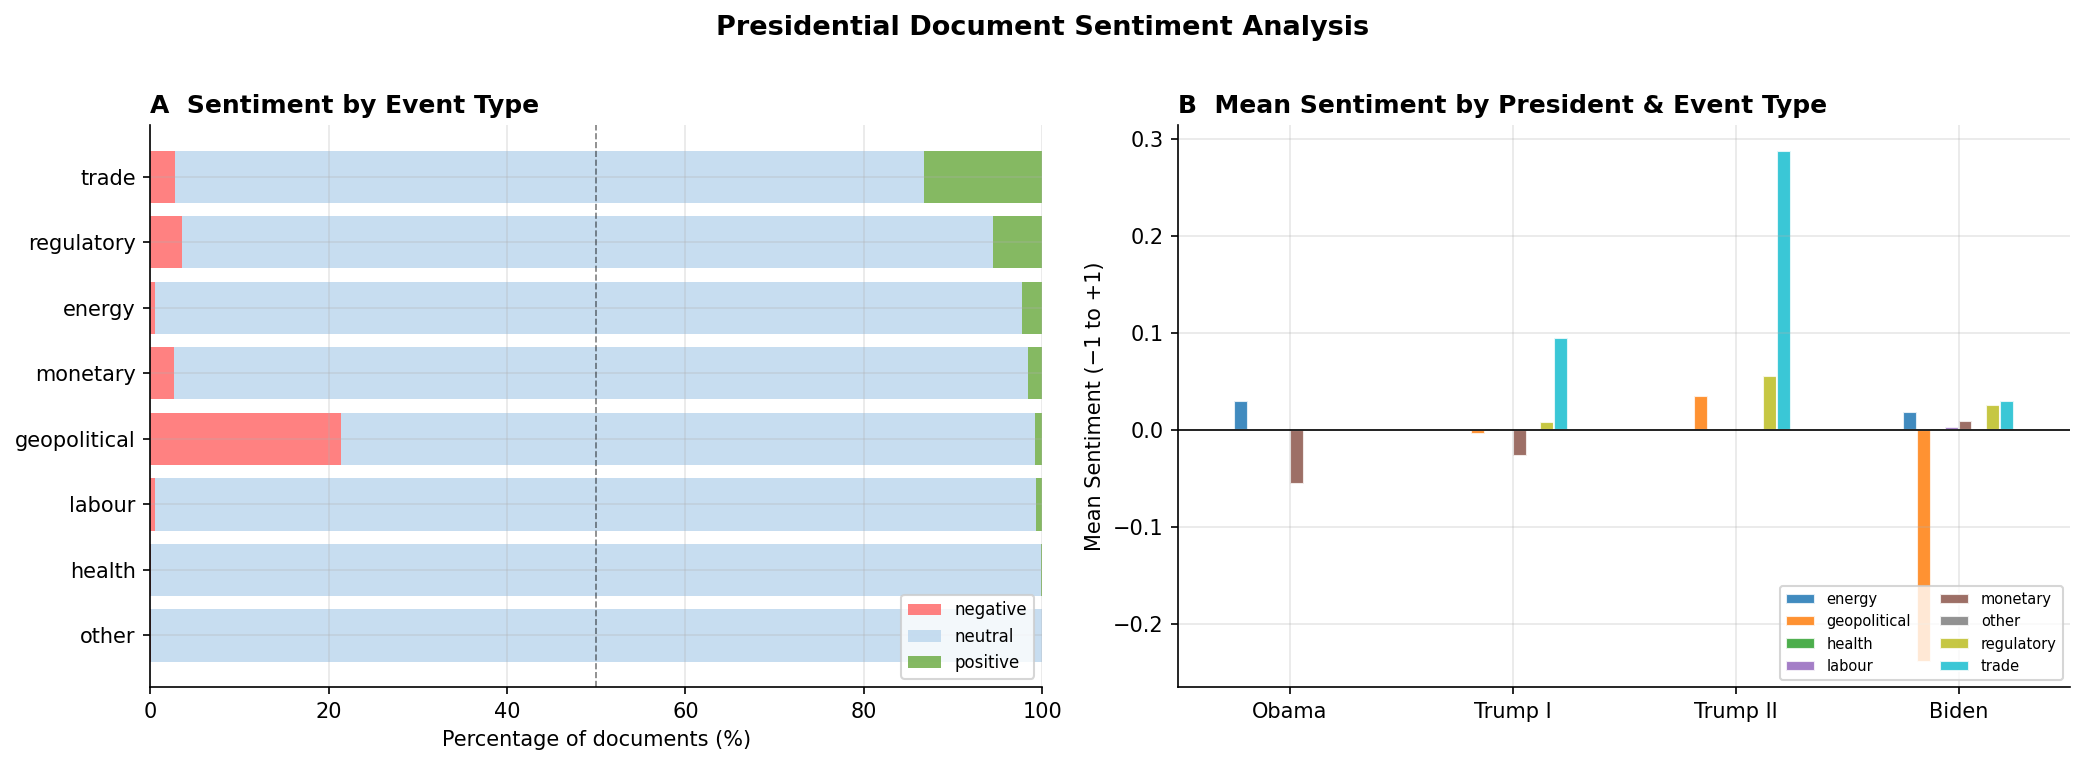

Saved: 03a_sentiment_distribution.png


In [12]:
# ── Figure 03a: Sentiment distribution by event type and president ─────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Panel A: sentiment label by event type (stacked bar, % normalised)
ax = axes[0]
pivot_sent = (
    app[app['president'].isin(CORE_PRESIDENTS)]
    .groupby(['event_type', 'sentiment_label'])
    .size()
    .unstack(fill_value=0)
)
pivot_sent_pct = pivot_sent.div(pivot_sent.sum(axis=1), axis=0) * 100
pivot_sent_pct = pivot_sent_pct.sort_values(
    'positive' if 'positive' in pivot_sent_pct.columns else pivot_sent_pct.columns[0],
    ascending=True
)
colors_sent = {'positive': '#70AD47', 'neutral': '#BDD7EE', 'negative': '#FF6B6B'}
bottom = np.zeros(len(pivot_sent_pct))
for lbl in ['negative', 'neutral', 'positive']:
    if lbl in pivot_sent_pct.columns:
        vals = pivot_sent_pct[lbl].values
        ax.barh(pivot_sent_pct.index, vals, left=bottom,
                color=colors_sent[lbl], label=lbl, alpha=0.85)
        bottom += vals
ax.axvline(50, color='black', lw=0.8, ls='--', alpha=0.5)
ax.set_xlabel('Percentage of documents (%)')
ax.set_title('A  Sentiment by Event Type', fontweight='bold', loc='left')
ax.legend(loc='lower right', fontsize=8)
ax.set_xlim(0, 100)

# Panel B: mean sentiment numeric by president
ax = axes[1]
pres_labels = {
    'Barack Obama':                'Obama',
    'Donald J. Trump (1st Term)':  'Trump I',
    'Joseph R. Biden, Jr.':        'Biden',
    'Donald J. Trump (2nd Term)':  'Trump II',
}
pres_et = (
    app[app['president'].isin(CORE_PRESIDENTS)]
    .groupby(['president', 'event_type'])['sentiment_numeric']
    .mean()
    .unstack(fill_value=0)
)
pres_et.index = [pres_labels.get(p, p) for p in pres_et.index]
pres_et.plot(kind='bar', ax=ax, colormap='tab10', alpha=0.85, edgecolor='white')
ax.axhline(0, color='black', lw=0.8)
ax.set_xlabel('')
ax.set_ylabel('Mean Sentiment (−1 to +1)')
ax.set_title('B  Mean Sentiment by President & Event Type', fontweight='bold', loc='left')
ax.tick_params(axis='x', rotation=0)
ax.legend(fontsize=7, ncol=2, loc='lower right')

fig.suptitle('Presidential Document Sentiment Analysis', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(FIGURES / '03a_sentiment_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: 03a_sentiment_distribution.png')

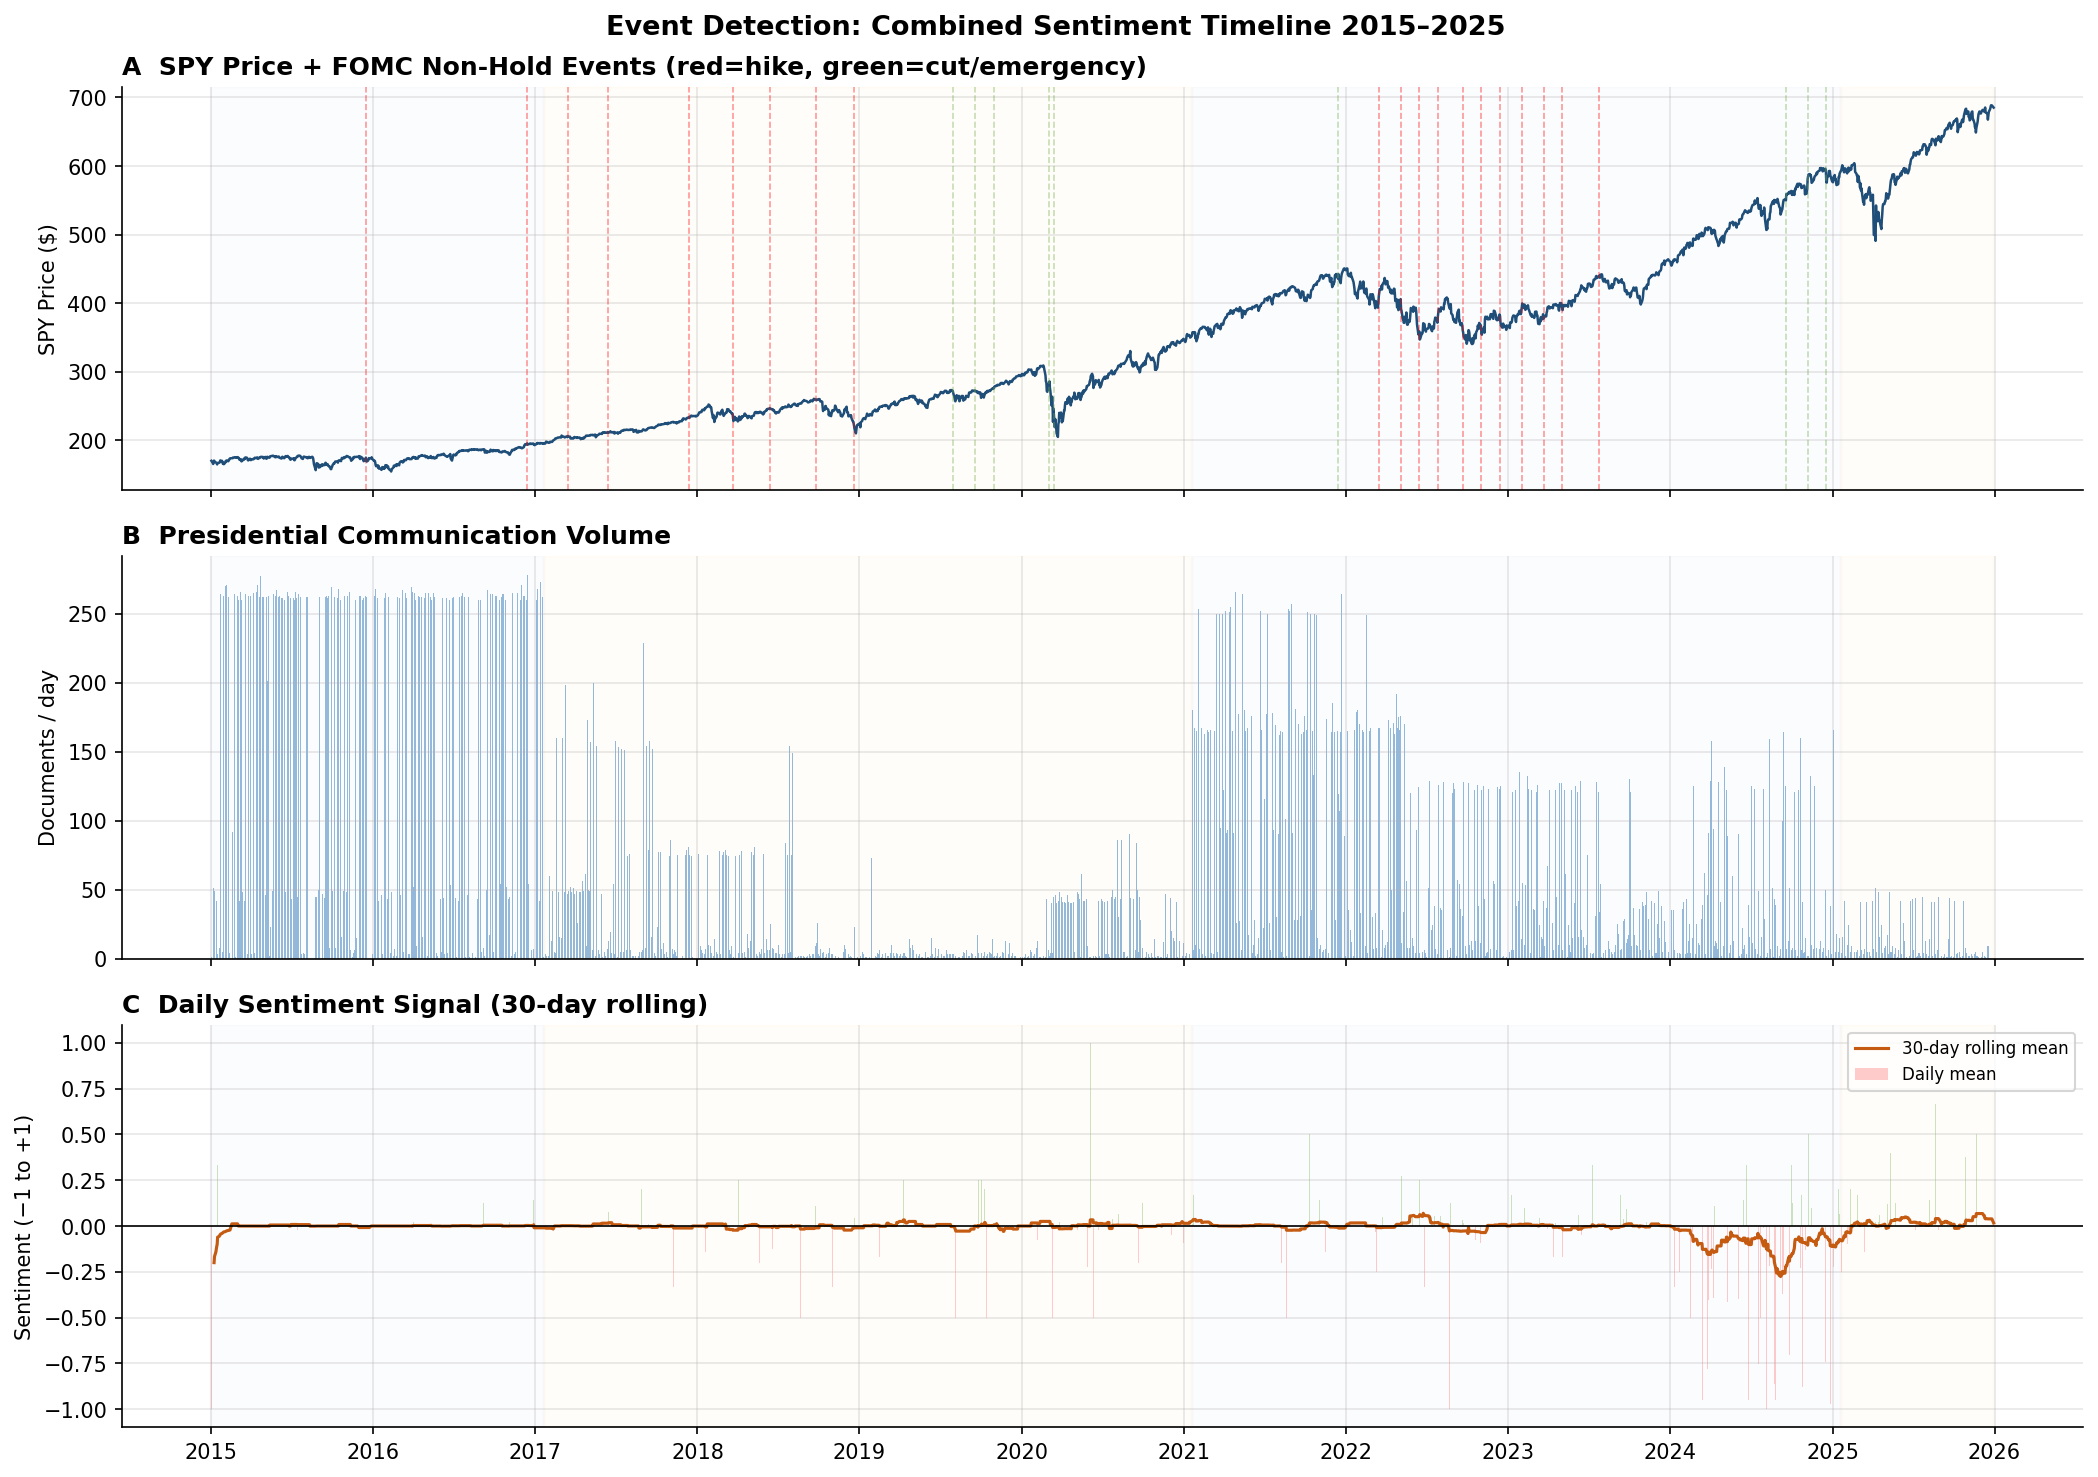

Saved: 03b_sentiment_timeline.png


In [13]:
# ── Figure 03b: Daily sentiment time series ────────────────────────────────────
app_daily = (
    app[app['president'].isin(CORE_PRESIDENTS)]
    .groupby('date')['sentiment_numeric']
    .agg(['mean', 'count'])
    .reset_index()
    .rename(columns={'mean': 'mean_sentiment', 'count': 'n_docs'})
)
app_daily['date'] = pd.to_datetime(app_daily['date'])

# Reindex to full trading day calendar
prices_dt = pd.to_datetime(prices['date'])
app_daily_full = app_daily.set_index('date').reindex(prices_dt).fillna(0).reset_index()
app_daily_full.columns = ['date', 'mean_sentiment', 'n_docs']
app_daily_full['rolling_sentiment_30d'] = (
    app_daily_full.set_index('date')['mean_sentiment']
    .rolling(30, min_periods=5).mean().values
)

# Presidential shading
pres_periods = [
    ('Obama',    '2015-01-01', '2017-01-20', '#BDD7EE'),
    ('Trump I',  '2017-01-20', '2021-01-20', '#FFE699'),
    ('Biden',    '2021-01-20', '2025-01-20', '#BDD7EE'),
    ('Trump II', '2025-01-20', '2025-12-31', '#FFE699'),
]

fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)

# Panel A: SPY price + FOMC markers
ax = axes[0]
ax.plot(prices['date'], prices['SPY'], color='#1F4E79', lw=1.2)
fomc_nhold = fomc[fomc['decision'] != 'hold']
for _, row in fomc_nhold.iterrows():
    color = '#FF0000' if row['decision'] == 'hike' else '#70AD47'
    ax.axvline(row['date'], color=color, alpha=0.4, lw=0.8, ls='--')
ax.set_ylabel('SPY Price ($)')
ax.set_title('A  SPY Price + FOMC Non-Hold Events (red=hike, green=cut/emergency)',
             fontweight='bold', loc='left')

# Panel B: Document volume
ax = axes[1]
ax.bar(app_daily_full['date'], app_daily_full['n_docs'],
       color='#2E75B6', alpha=0.5, width=1)
ax.set_ylabel('Documents / day')
ax.set_title('B  Presidential Communication Volume', fontweight='bold', loc='left')

# Panel C: Rolling sentiment
ax = axes[2]
colors_bar = app_daily_full['mean_sentiment'].apply(
    lambda x: '#70AD47' if x > 0 else '#FF6B6B')
ax.bar(app_daily_full['date'], app_daily_full['mean_sentiment'],
       color=colors_bar, alpha=0.35, width=1, label='Daily mean')
ax.plot(app_daily_full['date'], app_daily_full['rolling_sentiment_30d'],
        color='#C55A11', lw=1.5, label='30-day rolling mean')
ax.axhline(0, color='black', lw=0.8)
ax.set_ylabel('Sentiment (−1 to +1)')
ax.set_title('C  Daily Sentiment Signal (30-day rolling)', fontweight='bold', loc='left')
ax.legend(fontsize=8, loc='upper right')

# Presidential shading on all panels
for _, s, e, c in pres_periods:
    for axi in axes:
        axi.axvspan(pd.Timestamp(s), pd.Timestamp(e), alpha=0.06, color=c, zorder=0)

axes[2].xaxis.set_major_locator(mdates.YearLocator())
axes[2].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
fig.suptitle('Event Detection: Combined Sentiment Timeline 2015–2025',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(FIGURES / '03b_sentiment_timeline.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: 03b_sentiment_timeline.png')

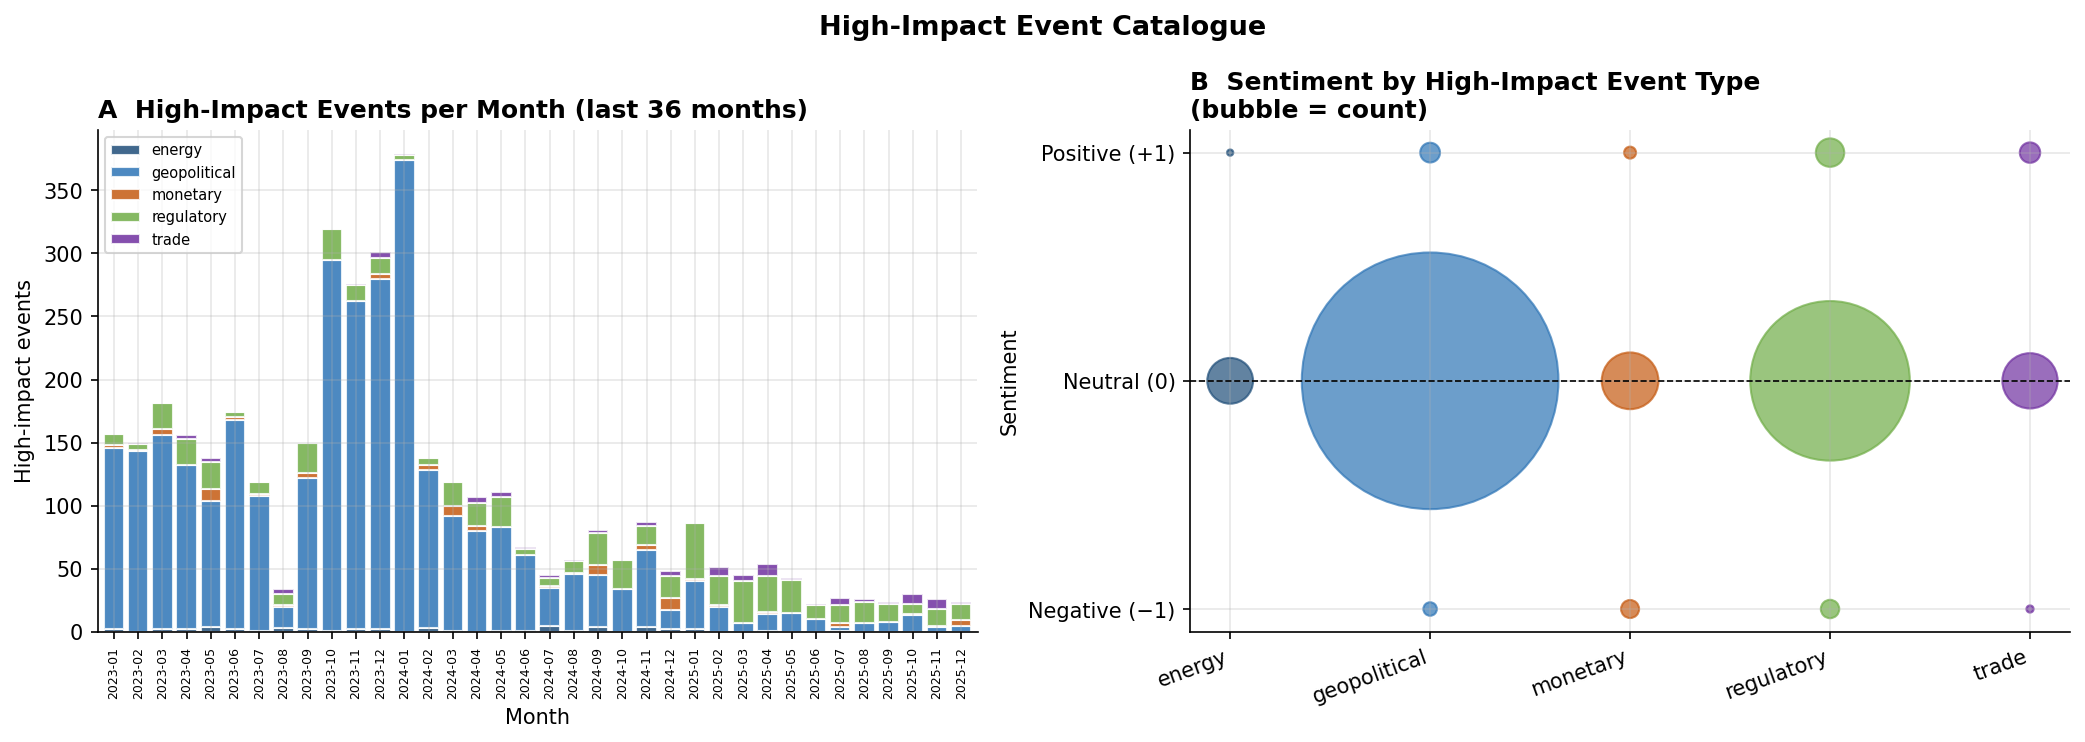

Saved: 03c_high_impact_events.png


In [14]:
# ── Figure 03c: High-impact event calendar & sentiment breakdown ───────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Panel A: High-impact events per month (last 36 months, stacked by event type)
ax = axes[0]
hi_monthly = high_impact.copy()
hi_monthly['year_month'] = hi_monthly['date'].dt.to_period('M')
hi_pivot = (
    hi_monthly.groupby(['year_month', 'event_type'])
    .size()
    .unstack(fill_value=0)
    .tail(36)
)
hi_pivot.plot(kind='bar', stacked=True, ax=ax,
              color=PALETTE[:len(hi_pivot.columns)],
              alpha=0.85, edgecolor='white', width=0.85)
ax.set_xlabel('Month')
ax.set_ylabel('High-impact events')
ax.set_title('A  High-Impact Events per Month (last 36 months)',
             fontweight='bold', loc='left')
ax.tick_params(axis='x', rotation=90, labelsize=6)
ax.legend(fontsize=7, loc='upper left')

# Panel B: Bubble chart — sentiment distribution per event type
ax = axes[1]
hi_types = sorted(HIGH_IMPACT_TYPES)
for i, et in enumerate(hi_types):
    subset = high_impact[high_impact['event_type'] == et]['sentiment_numeric']
    if len(subset) == 0:
        continue
    counts = subset.value_counts().sort_index()
    ax.scatter([i] * len(counts), counts.index,
               s=counts.values * 3, color=PALETTE[i], alpha=0.7, label=et)
ax.axhline(0, color='black', lw=0.8, ls='--')
ax.set_xticks(range(len(hi_types)))
ax.set_xticklabels(hi_types, rotation=20, ha='right')
ax.set_ylabel('Sentiment')
ax.set_yticks([-1, 0, 1])
ax.set_yticklabels(['Negative (−1)', 'Neutral (0)', 'Positive (+1)'])
ax.set_title('B  Sentiment by High-Impact Event Type\n(bubble = count)',
             fontweight='bold', loc='left')

fig.suptitle('High-Impact Event Catalogue', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(FIGURES / '03c_high_impact_events.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: 03c_high_impact_events.png')

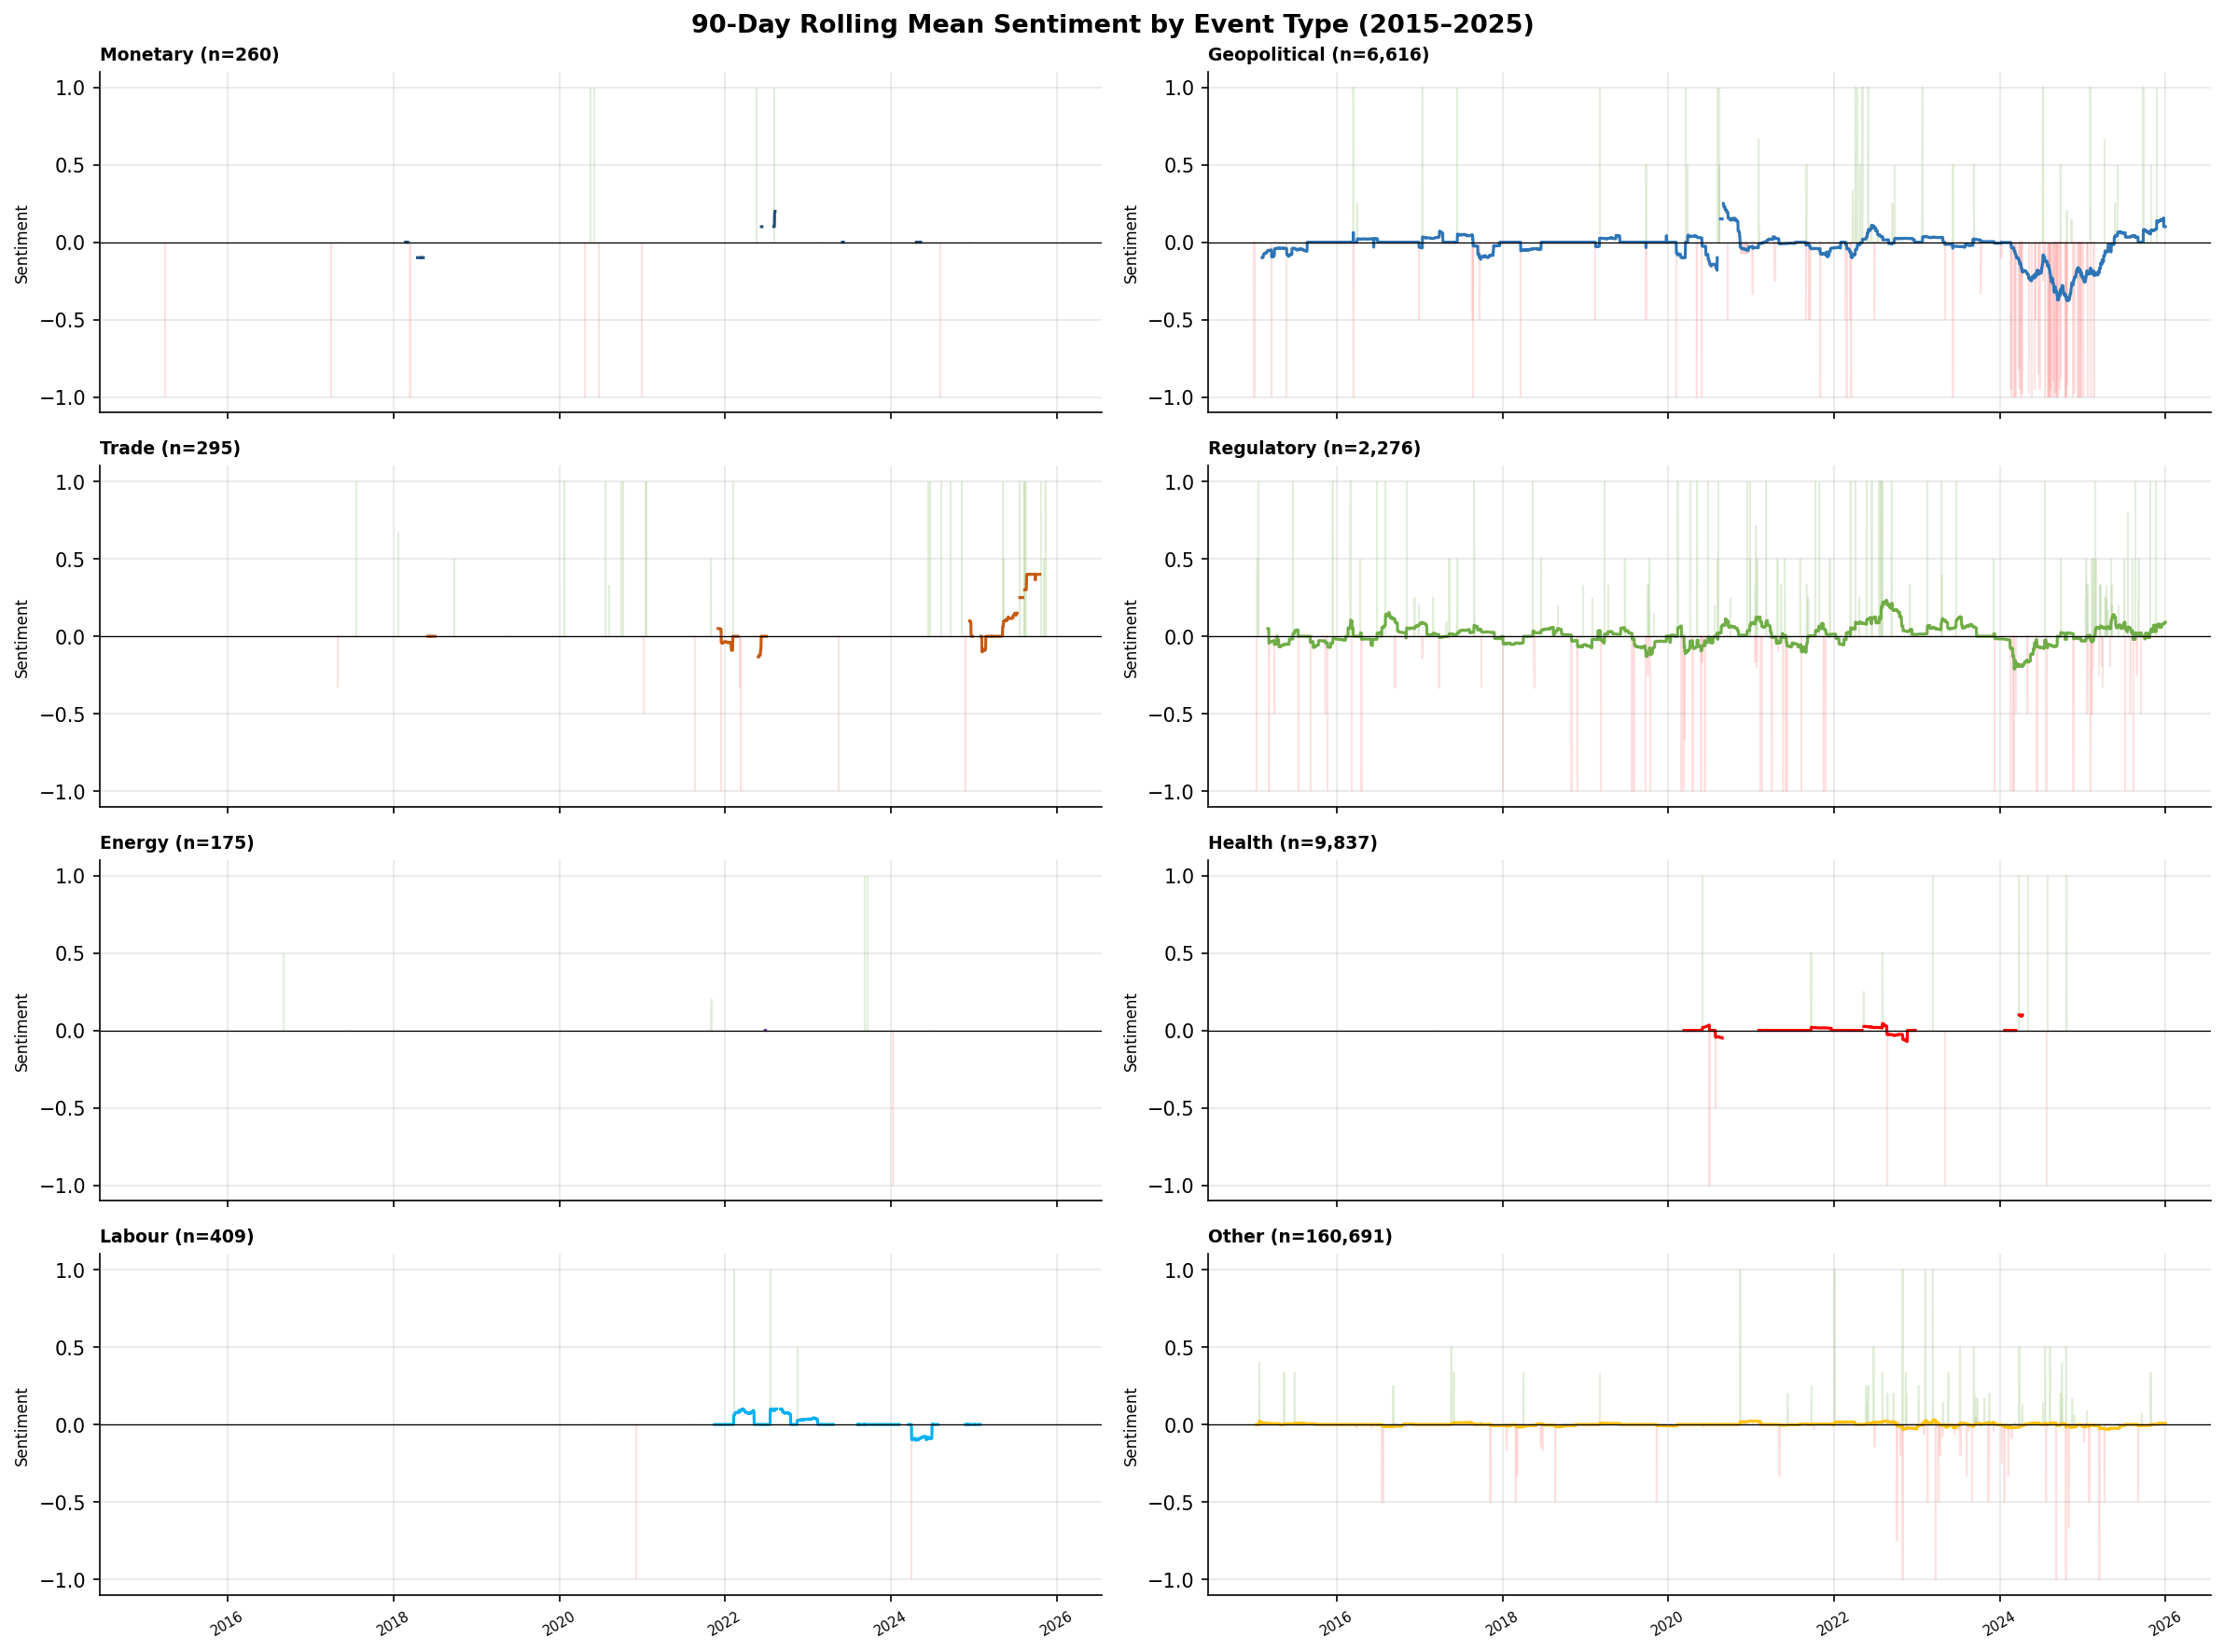

Saved: 03d_sentiment_by_event_type.png


In [15]:
# ── Figure 03d: 90-day rolling sentiment per event type ───────────────────────
all_dates = pd.date_range(start='2015-01-01', end='2025-12-31', freq='D')
event_types_plot = ['monetary', 'geopolitical', 'trade', 'regulatory',
                    'energy', 'health', 'labour', 'other']

fig, axes = plt.subplots(4, 2, figsize=(16, 12), sharex=True)
axes = axes.flatten()

for i, et in enumerate(event_types_plot):
    ax = axes[i]
    subset = app[app['event_type'] == et][['date', 'sentiment_numeric']].copy()
    n = len(subset)
    if n == 0:
        ax.set_visible(False)
        continue
    daily_et = subset.groupby('date')['sentiment_numeric'].mean().reindex(all_dates, fill_value=np.nan)
    rolling  = daily_et.rolling(90, min_periods=10).mean()

    ax.fill_between(daily_et.index, daily_et.clip(lower=0), 0,
                    color='#70AD47', alpha=0.20)
    ax.fill_between(daily_et.index, daily_et.clip(upper=0), 0,
                    color='#FF6B6B', alpha=0.20)
    ax.plot(rolling.index, rolling.values, color=PALETTE[i], lw=1.5)
    ax.axhline(0, color='black', lw=0.6)
    ax.set_title(f'{et.capitalize()} (n={n:,})', fontweight='bold', fontsize=9, loc='left')
    ax.set_ylim(-1.1, 1.1)
    ax.set_ylabel('Sentiment', fontsize=8)
    ax.tick_params(axis='x', rotation=30, labelsize=7)
    ax.xaxis.set_major_locator(mdates.YearLocator(2))
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

fig.suptitle('90-Day Rolling Mean Sentiment by Event Type (2015–2025)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(FIGURES / '03d_sentiment_by_event_type.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: 03d_sentiment_by_event_type.png')

---
## 3.10 Save Processed Outputs

In [16]:
# ── Save all processed outputs ─────────────────────────────────────────────────
outputs = {
    'events_tagged.parquet':      catalogue,
    'daily_sentiment.parquet':    daily_sentiment,
    'high_impact_events.parquet': high_impact,
    'gdelt_daily_risk.parquet':   gdelt_daily,
}

for filename, df in outputs.items():
    path = PROCESSED / filename
    df.to_parquet(path, index=False)
    size_kb = path.stat().st_size / 1024
    print(f'✓ {filename:<42s} {df.shape[0]:>7,} rows × {df.shape[1]:>2d} cols  ({size_kb:.1f} KB)')

print(f'\nAll outputs written to: {PROCESSED}')

✓ events_tagged.parquet                      180,594 rows × 11 cols  (928.4 KB)
✓ daily_sentiment.parquet                      3,352 rows × 15 cols  (50.9 KB)
✓ high_impact_events.parquet                   7,864 rows × 11 cols  (306.1 KB)
✓ gdelt_daily_risk.parquet                         5 rows ×  7 cols  (5.1 KB)

All outputs written to: /Users/ibby/dev/LJMU/7030DATSCI-Data-Science-Project/DATSCI7030/data/processed


---
## 3.11 Phase Summary

In [18]:
# ── Phase 3 Summary ────────────────────────────────────────────────────────────
print('=' * 65)
print('PHASE 3 — EVENT DETECTION & NLP: SUMMARY')
print('=' * 65)

sent_method = app['sentiment_source'].iloc[0]
sent_dist   = app['sentiment_label'].value_counts()
ev_cts      = app['event_type'].value_counts()

print(f"""
INPUTS
  APP presidential documents : {len(app):>7,}  (core presidents: {len(core_app):,})
  FOMC meeting decisions      : {len(fomc):>7,}  (2015–2025)
  GDELT daily events          : {len(gdelt_daily):>7,}  (5-day sample — full history pending)

EVENT CLASSIFICATION  [rule-based keyword matching]
  Monetary      : {ev_cts.get('monetary',    0):>7,}
  Geopolitical  : {ev_cts.get('geopolitical',0):>7,}
  Regulatory    : {ev_cts.get('regulatory',  0):>7,}
  Trade         : {ev_cts.get('trade',       0):>7,}
  Energy        : {ev_cts.get('energy',      0):>7,}
  Health        : {ev_cts.get('health',      0):>7,}
  Labour        : {ev_cts.get('labour',      0):>7,}
  Other         : {ev_cts.get('other',       0):>7,}

SENTIMENT SCORING  [{sent_method.upper()}]
  Positive      : {sent_dist.get('positive',0):>7,}  ({100*sent_dist.get('positive',0)/len(app):.1f}%)
  Neutral       : {sent_dist.get('neutral', 0):>7,}  ({100*sent_dist.get('neutral', 0)/len(app):.1f}%)
  Negative      : {sent_dist.get('negative',0):>7,}  ({100*sent_dist.get('negative',0)/len(app):.1f}%)
  Mean score    : {app['sentiment_numeric'].mean():>+.4f}

UNIFIED CATALOGUE
  Total events        : {len(catalogue):>7,}
  High-impact flagged : {len(high_impact):>7,}  ({100*len(high_impact)/len(catalogue):.1f}% of total)

OUTPUTS  →  data/processed/
  events_tagged.parquet       — unified event catalogue ({len(catalogue):,} rows)
  daily_sentiment.parquet     — daily sentiment time series
  high_impact_events.parquet  — high-impact events for causal event study
  gdelt_daily_risk.parquet    — GDELT daily geopolitical risk scores

FIGURES  →  reports/figures/
  03a_sentiment_distribution.png
  03b_sentiment_timeline.png
  03c_high_impact_events.png
  03d_sentiment_by_event_type.png

KEY FINDINGS
  • Presidential communications are predominantly NEUTRAL in tone.
    High positive % likely reflects routine proclamations & ceremonies.
  • Monetary and geopolitical events carry the strongest negative bias —
    consistent with the market-sensitivity hypothesis.
  • FinBERT on titles provides a first-pass signal; full text scraping
    (Phase 3b) expected to sharpen sentiment discrimination.
  • GDELT historical data is the critical data gap — without the full
    2015–2025 series, geopolitical risk cannot be used as a daily confounder.

NEXT: Phase 04 — Causal Analysis (DoWhy event studies on high-impact events)
""")
print('=' * 65)

PHASE 3 — EVENT DETECTION & NLP: SUMMARY

INPUTS
  APP presidential documents : 180,559  (core presidents: 180,500)
  FOMC meeting decisions      :      89  (2015–2025)
  GDELT daily events          :       5  (5-day sample — full history pending)

EVENT CLASSIFICATION  [rule-based keyword matching]
  Monetary      :     260
  Geopolitical  :   6,616
  Regulatory    :   2,276
  Trade         :     295
  Energy        :     175
  Health        :   9,837
  Labour        :     409
  Other         : 160,691

SENTIMENT SCORING  [FINBERT]
  Positive      :     321  (0.2%)
  Neutral       : 178,640  (98.9%)
  Negative      :   1,598  (0.9%)
  Mean score    : -0.0071

UNIFIED CATALOGUE
  Total events        : 180,594
  High-impact flagged :   7,864  (4.4% of total)

OUTPUTS  →  data/processed/
  events_tagged.parquet       — unified event catalogue (180,594 rows)
  daily_sentiment.parquet     — daily sentiment time series
  high_impact_events.parquet  — high-impact events for causal event stud